# exp08: Apakah label kondisi residual milik residualnya, atau milik XGBoost?

Notebook **pelapor**: membaca berkas hasil yang sudah ada, tidak melatih model,
tidak menulis ke `results/`, tidak mengimpor `src/experiments` maupun `tools`.

## 1. Ringkasan

**Pertanyaan yang dijawab.** RQ2, pada sumbu keluarga model residual. Penelitian ini
menggolongkan sebuah konfigurasi ke kondisi residual berstruktur atau kondisi residual
*noise* berdasarkan tanda `resid_val_r2`, yaitu R² validasi dari model residual XGBoost yang
dipilih protokol. Reviewer ronde 2 pada butir R2-2 menunjuk celah logikanya. Nilai negatif
hanya menunjukkan bahwa model residual ini gagal, dan belum menunjukkan bahwa tidak ada model
residual yang dapat berhasil.

exp08 menutup celah tersebut dengan memasang **enam keluarga model residual** yang memiliki
bias induktif dan kapasitas berbeda pada residual *cross-fitted* yang sama, kemudian
melaporkan pembacaan yang paling optimistis.

**Tidak ada ramalan pra-registrasi**; exp08 adalah tanggapan reviewer.

**Dipakai di mana.**

| Naskah | Bagian |
|---|---|
| Disertasi | Subbab 5.6, **Tabel 5.9** |
| Paper IJIES | Subbab 4.6 |

## 2. Lingkungan

In [1]:
# Notebook pelapor: HANYA MEMBACA.
# Tidak melatih model, tidak mengimpor src/experiments atau tools (agar TensorFlow
# tidak ikut termuat), dan tidak pernah menulis ke results/, data/ atau raw/.
%matplotlib inline
from pathlib import Path
import ast, json, hashlib, datetime, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cari_root(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / "results").is_dir() and (c / "src" / "experiments").is_dir():
            return c
    raise RuntimeError("root repositori tidak ditemukan dari " + str(p))


ROOT = cari_root(Path.cwd().resolve())
RES = ROOT / "results"

pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.max_rows", 200)

print("Root repositori :", ROOT)
print("Folder hasil    :", RES.relative_to(ROOT),
      f"({sum(1 for f in RES.rglob('*') if f.is_file())} berkas)")
print("Dijalankan      :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


def idn(x, d=2, tanda=False):
    """Format angka gaya Indonesia (koma desimal, titik ribuan)."""
    s = f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    if tanda and x > 0:
        s = "+" + s
    return s.replace("-", "\u2212")


def baca(nama, **kw):
    """Baca satu berkas di results/ sebagai DataFrame. Read-only."""
    f = RES / nama
    if not f.exists():
        raise FileNotFoundError(f"{nama} tidak ada di results/")
    return pd.read_csv(f, **kw)


def potongan(relpath, nama=None, awal=None, akhir=None):
    """Tampilkan potongan kode dengan membaca berkas sebagai TEKS.

    Memakai ``ast`` untuk menemukan batas fungsi/konstanta, sehingga modul
    eksperimen tidak perlu diimpor.
    """
    f = ROOT / relpath
    teks = f.read_text(encoding="utf-8")
    baris = teks.splitlines()
    if nama is not None:
        pohon = ast.parse(teks)
        ketemu = False
        for n in ast.walk(pohon):
            if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and n.name == nama:
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
            if isinstance(n, ast.Assign) and any(getattr(t, "id", None) == nama for t in n.targets):
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
        if not ketemu:
            raise KeyError(f"'{nama}' tidak ditemukan di {relpath}")
    awal = awal or 1
    akhir = akhir or len(baris)
    lebar = len(str(akhir))
    print(f"--- {relpath}:{awal}-{akhir} " + "-" * max(0, 74 - len(relpath)))
    for i in range(awal, akhir + 1):
        print(f"{str(i).rjust(lebar)} | {baris[i - 1]}")


def git(*args):
    """Jalankan perintah git read-only di root repositori."""
    try:
        r = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() if r.returncode == 0 else ""
    except Exception:
        return ""


def asal(nama_meta=None, berkas_hasil=None, skrip=None, log=None):
    """Cetak asal-usul: meta.json, commit, dan log run bila ada."""
    if nama_meta:
        f = RES / nama_meta
        if f.exists():
            print("meta.json " + "-" * 60)
            print(json.dumps(json.loads(f.read_text(encoding="utf-8")), indent=2, ensure_ascii=False))
            print()
    for label, path in [("berkas hasil", berkas_hasil), ("skrip", skrip)]:
        if path:
            print(f"commit terakhir yang menyentuh {label} ({path})")
            print("  " + (git("log", "-1", "--date=short", "--format=%h  %ad  %s", "--", path) or "(tidak terbaca)"))
    if log:
        f = RES / "logs" / log
        print()
        if f.exists():
            print(f"results/logs/{log}  ({f.stat().st_size} bytes, "
                  f"ditulis {datetime.datetime.fromtimestamp(f.stat().st_mtime):%Y-%m-%d %H:%M})")
        else:
            print(f"results/logs/{log} tidak ada di klon ini (berkas *.log diabaikan git).")

Root repositori : I:\Shared drives\Riset S3\Experiment S3 Code\antgravity_riset\AR-LRX_hybrid-forecasting


Folder hasil    : results (179 berkas)
Dijalankan      : 2026-09-29 06:59


In [2]:
# Pembanding angka CSV terhadap angka yang tercetak di disertasi.
# Tidak ada angka yang dibetulkan di sini; ketidakcocokan hanya dilaporkan.
_cek = []


def cek(butir, nilai_csv, nilai_naskah, tol=0.005, d=4, rujukan=""):
    beda = abs(float(nilai_csv) - float(nilai_naskah))
    ok = beda <= tol
    _cek.append({
        "Butir": butir,
        "Rujukan naskah": rujukan,
        "Dari CSV": round(float(nilai_csv), d),
        "Di disertasi": float(nilai_naskah),
        "|selisih|": round(beda, 6),
        "Status": "COCOK" if ok else "TIDAK COCOK",
    })
    return ok


def laporan_cek():
    t = pd.DataFrame(_cek)
    n_ok = int((t.Status == "COCOK").sum())
    display(t)
    print()
    print(f"RINGKASAN: {n_ok} dari {len(t)} angka COCOK dengan naskah disertasi.")
    buruk = t[t.Status == "TIDAK COCOK"]
    if len(buruk):
        print()
        print("!" * 78)
        print("ADA ANGKA YANG TIDAK COCOK. Tidak dibetulkan di notebook ini.")
        print("Laporkan butir berikut sebelum notebook dipakai sebagai lampiran:")
        for _, r in buruk.iterrows():
            print(f"  - {r.Butir} ({r['Rujukan naskah']}): "
                  f"CSV {r['Dari CSV']} vs naskah {r['Di disertasi']}")
        print("!" * 78)
    else:
        print("Tidak ada selisih di luar toleransi pembulatan.")
    return t

## 3. Desain eksperimen

**Enam keluarga model residual**, masing-masing atas rentang hiperparameternya sendiri:
XGBoost, LightGBM, *random forest*, kNN, *ridge*, dan MLP. Definisinya dibaca sebagai teks:

In [3]:
potongan("tools/exp08_learner_stability.py", nama="learners")

--- tools/exp08_learner_stability.py:91-125 ------------------------------------------
 91 | def learners(xgb_grid, quick):
 92 |     from sklearn.ensemble import RandomForestRegressor
 93 |     from sklearn.linear_model import Ridge
 94 |     from sklearn.neighbors import KNeighborsRegressor
 95 |     from sklearn.neural_network import MLPRegressor
 96 |     from sklearn.pipeline import make_pipeline
 97 |     from sklearn.preprocessing import StandardScaler
 98 | 
 99 |     S = P.SEED
100 |     L = {"XGBoost": [(json.dumps(p, sort_keys=True), (lambda p=p: P.make_xgb(p)))
101 |                      for p in P.param_grid_list(xgb_grid)]}
102 | 
103 |     def lgbm(leaves, n):
104 |         import lightgbm as lgb
105 |         return lgb.LGBMRegressor(num_leaves=leaves, n_estimators=n, learning_rate=0.05,
106 |                                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
107 |                                  random_state=S, n_jobs=-1, verbose=-1)
108 |     L["

**Yang dilaporkan per konfigurasi:**

- R² validasi setiap model residual pada setiap setelan hiperparameter;
- R² validasi **terbaik** atas semuanya, yaitu pembacaan paling optimistis yang bias ke atas
  karena pencariannya sendiri;
- jumlah model residual yang mencapai R² validasi positif.

**Sisi metodologisnya.** Residual yang dipakai identik untuk keenam keluarga, dan yang diubah
hanya model residualnya. Apabila seluruh keluarga gagal pada residual yang sama, kegagalan
tersebut merupakan sifat residualnya dan tidak sifat XGBoost.

**Data.** PharmaSales 20 konfigurasi berbeda (tahap pertama linier) dan Rossmann 9 baris
(tiga varian fitur × tiga tahap pertama), dengan subsampel 100.000 baris untuk Rossmann.

## 4. Asal-usul hasil

In [4]:
RUN_EXPERIMENT = False

PERINTAH = [
    "python tools/exp08_learner_stability.py --part pharma",
    "python tools/exp08_learner_stability.py --part rossmann",
    "python tools/exp08_learner_stability.py --part summary",
]

if RUN_EXPERIMENT:
    for c in PERINTAH:
        print(">>", c)
        r = subprocess.run(c, shell=True, cwd=ROOT)
        print("   kode keluar:", r.returncode)
else:
    print("RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.")
    print()
    print("Perintah asli yang menghasilkan berkas di results/:")
    for c in PERINTAH:
        print("   ", c)
    print()
    print('Runtime asli sekitar 2 jam, dibagi dua bagian. Menyimpan checkpoint dan dapat dilanjutkan.')

RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.

Perintah asli yang menghasilkan berkas di results/:
    python tools/exp08_learner_stability.py --part pharma
    python tools/exp08_learner_stability.py --part rossmann
    python tools/exp08_learner_stability.py --part summary

Runtime asli sekitar 2 jam, dibagi dua bagian. Menyimpan checkpoint dan dapat dilanjutkan.


In [5]:
asal(berkas_hasil="results/exp08_summary.csv", skrip="tools/exp08_learner_stability.py")

commit terakhir yang menyentuh berkas hasil (results/exp08_summary.csv)


  e4f0caf  2026-09-16  Rolling-origin, multi-seed and learner-stability results (R1-6, R2-1, R2-2, R2-4)
commit terakhir yang menyentuh skrip (tools/exp08_learner_stability.py)


  d48a0c8  2026-09-17  Enable LightGBM row bagging in the baseline and re-run dependent analyses; add exp08 and helper scripts


## 5. Hasil

In [6]:
s8 = baca("exp08_summary.csv")
raw8 = baca("exp08_learner_stability.csv")

print(f"exp08_summary.csv          : {s8.shape[0]} baris")
print(f"exp08_learner_stability.csv: {raw8.shape[0]} baris (satu baris per pemasangan model)")
print(f"Keluarga model residual    : {s8.n_learners.iloc[0]}")
print()
ph8 = s8[s8.dataset == "pharma"]
ro8 = s8[s8.dataset == "rossmann"]
print(f"PharmaSales : {len(ph8)} konfigurasi berbeda")
print(f"Rossmann    : {len(ro8)} konfigurasi (3 varian fitur x 3 tahap pertama)")

exp08_summary.csv          : 29 baris
exp08_learner_stability.csv: 776 baris (satu baris per pemasangan model)
Keluarga model residual    : 6

PharmaSales : 20 konfigurasi berbeda
Rossmann    : 9 konfigurasi (3 varian fitur x 3 tahap pertama)


### 5.1 Tabel 5.9

In [7]:
KOL = ["val_r2 | XGBoost", "val_r2 | LightGBM", "val_r2 | RandomForest",
       "val_r2 | kNN", "val_r2 | Ridge", "val_r2 | MLP"]
vn = {"V1_customers_dropped": "V1", "V2_customers_lagged": "V2", "V3_sales_lagged": "V3"}

rows = [{
    "Data": "PharmaSales (20 konfigurasi)",
    "Tahap pertama": "linier",
    "XGBoost (R2 validasi)": f"{ph8.xgb_best_val_r2.min():.3f} - {ph8.xgb_best_val_r2.max():.3f}",
    "Keluarga lain terbaik": f"{ph8.other_best_val_r2.min():.3f} - {ph8.other_best_val_r2.max():.3f}",
    "Pemodel dengan R2 validasi > 0": f"{ph8.n_learners_val_r2_gt0.min()}-{ph8.n_learners_val_r2_gt0.max()} dari 6",
}]
for _, r in ro8.iterrows():
    rows.append({
        "Data": f"Rossmann {vn[r.config.split('|')[1]]}",
        "Tahap pertama": r.stage1,
        "XGBoost (R2 validasi)": f"{r.xgb_best_val_r2:.3f} (uji {r.xgb_test_r2:.3f})",
        "Keluarga lain terbaik": f"{r.other_best_val_r2:.3f} ({r.other_best_learner})",
        "Pemodel dengan R2 validasi > 0": f"{int(r.n_learners_val_r2_gt0)} dari 6",
    })
display(pd.DataFrame(rows))

,Data,Tahap pertama,XGBoost (R2 validasi),Keluarga lain terbaik,Pemodel dengan R2 validasi > 0
0,PharmaSales (20 konfigurasi),linier,-1.157 - 0.015,-0.613 - 0.026,0-3 dari 6
1,Rossmann V1,linear,0.587 (uji 0.656),0.519 (LightGBM),5 dari 6
2,Rossmann V1,structural,-0.021 (uji -0.052),-0.028 (MLP),0 dari 6
3,Rossmann V1,struct_linear,-0.028 (uji -0.035),-0.034 (MLP),0 dari 6
4,Rossmann V2,linear,0.534 (uji 0.720),0.438 (LightGBM),5 dari 6
5,Rossmann V2,structural,0.087 (uji 0.242),-0.026 (RandomForest),1 dari 6
6,Rossmann V2,struct_linear,0.084 (uji 0.244),-0.043 (LightGBM),1 dari 6
7,Rossmann V3,linear,0.436 (uji 0.701),0.368 (LightGBM),5 dari 6
8,Rossmann V3,structural,0.117 (uji 0.304),0.012 (MLP),3 dari 6
9,Rossmann V3,struct_linear,0.097 (uji 0.297),-0.012 (LightGBM),1 dari 6


### 5.2 Berapa banyak pemasangan model yang berhasil pada data obat?

In [8]:
# Berapa banyak pemasangan model pada PharmaSales, dan berapa yang mencapai R2 > 0?
p8 = raw8[raw8.dataset == "pharma"] if "dataset" in raw8.columns else raw8[
    raw8.config.str.startswith("pharma")]
n_fit = len(p8)
n_pos = int((p8.val_r2 > 0).sum()) if "val_r2" in p8.columns else np.nan
print(f"Kolom exp08_learner_stability.csv: {list(raw8.columns)[:10]} ...")
print()
print(f"Pemasangan model pada PharmaSales : {n_fit}")
if not np.isnan(n_pos):
    print(f"Yang mencapai R2 validasi positif : {n_pos}  ({100*n_pos/n_fit:.1f}%)")
    print(f"R2 validasi positif terbesar      : {p8[p8.val_r2 > 0].val_r2.max():.3f}")
print()
print("Sebaran R2 validasi terbaik per konfigurasi PharmaSales (seluruh 6 keluarga):")
print(ph8[["xgb_best_val_r2", "other_best_val_r2", "n_learners_val_r2_gt0"]].describe().round(4).to_string())

Kolom exp08_learner_stability.csv: ['config', 'stage1', 'learner', 'setting', 'subsampled', 'val_r2', 'test_r2_refit', 'is_best_on_val', 'runtime_s'] ...

Pemasangan model pada PharmaSales : 560
Yang mencapai R2 validasi positif : 19  (3.4%)
R2 validasi positif terbesar      : 0.026

Sebaran R2 validasi terbaik per konfigurasi PharmaSales (seluruh 6 keluarga):
       xgb_best_val_r2  other_best_val_r2  n_learners_val_r2_gt0
count          20.0000            20.0000                 20.000
mean           -0.2078            -0.0515                  0.550
std             0.2876             0.1393                  0.887
min            -1.1574            -0.6127                  0.000
25%            -0.2731            -0.0401                  0.000
50%            -0.0933            -0.0077                  0.000
75%            -0.0206             0.0009                  1.000
max             0.0146             0.0265                  3.000


### 5.3 Sebaran

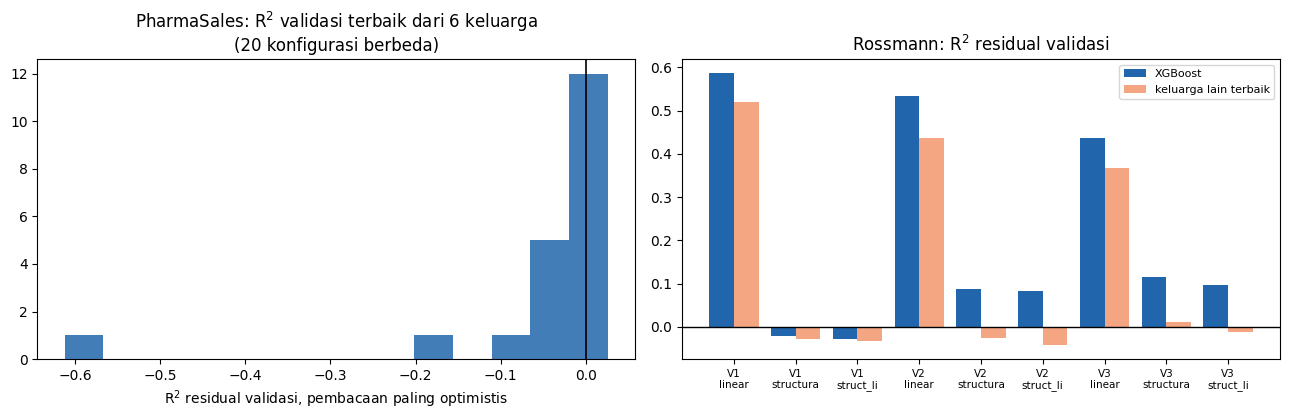

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].hist(ph8.other_best_val_r2, bins=14, color="#2166ac", alpha=0.85)
axes[0].axvline(0, color="black", lw=1.2)
axes[0].set_title("PharmaSales: R$^2$ validasi terbaik dari 6 keluarga\n(20 konfigurasi berbeda)")
axes[0].set_xlabel("R$^2$ residual validasi, pembacaan paling optimistis")

x = np.arange(len(ro8))
axes[1].bar(x - 0.2, ro8.xgb_best_val_r2, 0.4, label="XGBoost", color="#2166ac")
axes[1].bar(x + 0.2, ro8.other_best_val_r2, 0.4, label="keluarga lain terbaik", color="#f4a582")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{vn[r.config.split('|')[1]]}\n{r.stage1[:9]}" for _, r in ro8.iterrows()],
                        fontsize=7.5)
axes[1].set_title("Rossmann: R$^2$ residual validasi")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 5.4 Apakah pengambilan subsampel menggeser angkanya?

Rossmann di exp08 memakai subsampel 100.000 baris. Sel berikut membandingkannya dengan
`resid_val_r2` panel penuh dari exp05b.

In [10]:
# exp08 memakai subsampel 100.000 baris pada Rossmann. Seberapa jauh angkanya
# bergeser dari panel penuh? Pembandingnya resid_val_r2 exp05b, yaitu nilai yang
# dipilih protokol pada panel penuh.
b5 = baca("exp05b_rossmann_arlrx_audit.csv")
b5 = b5[b5.resid_val_r2.notna()][["feature_set", "stage1", "resid_val_r2"]].rename(
    columns={"feature_set": "varian", "resid_val_r2": "exp05b panel penuh"})
e8 = ro8[["config", "stage1", "xgb_best_val_r2"]].copy()
e8["varian"] = e8.config.str.split("|").str[1]
e8 = e8.rename(columns={"xgb_best_val_r2": "exp08 subsampel"})[
    ["varian", "stage1", "exp08 subsampel"]]

band = b5.merge(e8, on=["varian", "stage1"], how="inner")
band["varian"] = band.varian.map(vn)
band["selisih"] = band["exp08 subsampel"] - band["exp05b panel penuh"]
display(band.round(4).reset_index(drop=True))
print()
print(f"Selisih |terbesar| : {band.selisih.abs().max():.4f}")
print(f"Tanda R2 berbeda   : {int((np.sign(band['exp05b panel penuh']) != np.sign(band['exp08 subsampel'])).sum())} "
      f"dari {len(band)} baris")
print()
print("Kedua kolom tidak sepadan sepenuhnya: exp05b melaporkan nilai yang DIPILIH protokol,")
print("sedangkan exp08 melaporkan nilai TERBAIK atas seluruh pencarian hiperparameter.")
print("Perbandingan ini hanya menunjukkan bahwa pengambilan subsampel tidak mengubah")
print("tanda R2, sehingga label kondisi residual tidak berpindah.")

,varian,stage1,exp05b panel penuh,exp08 subsampel,selisih
0,V1,linear,0.5872,0.5872,0.0000
1,V1,structural,-0.0220,-0.0209,0.0011
2,V1,struct_linear,-0.0278,-0.0278,0.0000
3,V2,linear,0.5336,0.5336,0.0000
4,V2,structural,0.0751,0.0872,0.0121
5,V2,struct_linear,0.0840,0.0840,0.0000
6,V3,linear,0.4361,0.4361,0.0000
7,V3,structural,0.1027,0.1165,0.0138
8,V3,struct_linear,0.0972,0.0972,0.0000



Selisih |terbesar| : 0.0138
Tanda R2 berbeda   : 0 dari 9 baris

Kedua kolom tidak sepadan sepenuhnya: exp05b melaporkan nilai yang DIPILIH protokol,
sedangkan exp08 melaporkan nilai TERBAIK atas seluruh pencarian hiperparameter.
Perbandingan ini hanya menunjukkan bahwa pengambilan subsampel tidak mengubah
tanda R2, sehingga label kondisi residual tidak berpindah.


## 6. Cek kecocokan dengan angka disertasi

In [11]:
cek("Tabel 5.9: jumlah keluarga pemodel", s8.n_learners.iloc[0], 6, tol=0, rujukan="Tabel 5.9")
cek("Tabel 5.9: jumlah konfigurasi PharmaSales", len(ph8), 20, tol=0, rujukan="Tabel 5.9")
cek("Tabel 5.9: jumlah baris Rossmann", len(ro8), 9, tol=0, rujukan="Tabel 5.9")

# --- Subbab 5.6, kalimat pertama -------------------------------------------
cek("Subbab 5.6: pemasangan model PharmaSales", n_fit, 560, tol=0, rujukan="Subbab 5.6")
cek("Subbab 5.6: yang mencapai R2 validasi positif", n_pos, 19, tol=0, rujukan="Subbab 5.6")
cek("Subbab 5.6: persentasenya", 100 * n_pos / n_fit, 3.4, tol=0.05, rujukan="Subbab 5.6")
cek("Subbab 5.6: R2 validasi positif terbesar", p8[p8.val_r2 > 0].val_r2.max(), 0.026,
    tol=0.0006, rujukan="Subbab 5.6")

# --- Kesepakatan label pada ambang praktis 0,01 -----------------------------
cek("Subbab 5.6: label XGBoost sepakat dengan keluarga lain (dari 20)",
    int(ph8.agree_at_thr.sum()), 16, tol=0, rujukan="Subbab 5.6")

# --- Rossmann, tahap pertama linier ----------------------------------------
lin8 = ro8[ro8.stage1 == "linear"]
cek("Subbab 5.6: Rossmann S1 linier, keluarga alternatif terbaik, minimum",
    lin8.other_best_val_r2.min(), 0.37, tol=0.005, rujukan="Subbab 5.6")
cek("Subbab 5.6: Rossmann S1 linier, keluarga alternatif terbaik, maksimum",
    lin8.other_best_val_r2.max(), 0.52, tol=0.005, rujukan="Subbab 5.6")

# --- Rossmann V2/V3, ansambel pohon selain XGBoost pada data uji ------------
# "ansambel pohon mencapai nilai uji positif 0,08 sampai 0,15": LightGBM dan
# RandomForest (XGBoost adalah pemodel acuan), V2 dan V3, S1 struktural dan
# struct_linear, baris yang terbaik pada data validasi.
r8 = raw8[raw8.config.str.startswith("rossmann")]
pohon8 = r8[(r8.stage1.isin(["structural", "struct_linear"]))
            & (r8.config.str.contains("V2|V3"))
            & (r8.learner.isin(["LightGBM", "RandomForest"]))
            & (r8.is_best_on_val)]
cek("Subbab 5.6: ansambel pohon V2/V3, R2 uji minimum", pohon8.test_r2_refit.min(), 0.08,
    tol=0.005, rujukan="Subbab 5.6")
cek("Subbab 5.6: ansambel pohon V2/V3, R2 uji maksimum", pohon8.test_r2_refit.max(), 0.15,
    tol=0.005, rujukan="Subbab 5.6")

# --- V1 struktural: noise bagi semua keluarga -------------------------------
v1_8 = ro8[(ro8.stage1 == "structural") & (ro8.config.str.contains("V1"))]
cek("Subbab 5.6: V1 struktural, pemodel dengan R2 validasi > 0",
    int(v1_8.n_learners_val_r2_gt0.iloc[0]), 0, tol=0, rujukan="Subbab 5.6")

hasil_cek = laporan_cek()

print()
print("CATATAN PENELUSURAN")
print("Rentang '0,075 sampai 0,238' pada Tabel 5.1 BUKAN berasal dari exp08.")
print("Itu resid_val_r2 yang dipilih protokol pada exp05b/exp05d, sedangkan")
print("xgb_best_val_r2 di exp08 adalah nilai TERBAIK atas seluruh pencarian")
print(f"hiperparameter, yang di sini berkisar {ro8.xgb_best_val_r2.min():.4f} sampai "
      f"{ro8.xgb_best_val_r2.max():.4f}.")
print("Kedua besaran itu berbeda definisi dan tidak boleh saling dicocokkan.")

,Butir,Rujukan naskah,Dari CSV,Di disertasi,|selisih|,Status
0,Tabel 5.9: jumlah keluarga pemodel,Tabel 5.9,6.0000,6.000,0.000000,COCOK
1,Tabel 5.9: jumlah konfigurasi PharmaSales,Tabel 5.9,20.0000,20.000,0.000000,COCOK
2,Tabel 5.9: jumlah baris Rossmann,Tabel 5.9,9.0000,9.000,0.000000,COCOK
3,Subbab 5.6: pemasangan model PharmaSales,Subbab 5.6,560.0000,560.000,0.000000,COCOK
4,Subbab 5.6: yang mencapai R2 validasi positif,Subbab 5.6,19.0000,19.000,0.000000,COCOK
5,Subbab 5.6: persentasenya,Subbab 5.6,3.3929,3.400,0.007143,COCOK
6,Subbab 5.6: R2 validasi positif terbesar,Subbab 5.6,0.0265,0.026,0.000485,COCOK
7,Subbab 5.6: label XGBoost sepakat dengan keluarga lain (dari 20),Subbab 5.6,16.0000,16.000,0.000000,COCOK
8,"Subbab 5.6: Rossmann S1 linier, keluarga alternatif terbaik, minimum",Subbab 5.6,0.3684,0.370,0.001589,COCOK
9,"Subbab 5.6: Rossmann S1 linier, keluarga alternatif terbaik, maksimum",Subbab 5.6,0.5190,0.520,0.001011,COCOK



RINGKASAN: 13 dari 13 angka COCOK dengan naskah disertasi.
Tidak ada selisih di luar toleransi pembulatan.

CATATAN PENELUSURAN
Rentang '0,075 sampai 0,238' pada Tabel 5.1 BUKAN berasal dari exp08.
Itu resid_val_r2 yang dipilih protokol pada exp05b/exp05d, sedangkan
xgb_best_val_r2 di exp08 adalah nilai TERBAIK atas seluruh pencarian
hiperparameter, yang di sini berkisar -0.0278 sampai 0.5872.
Kedua besaran itu berbeda definisi dan tidak boleh saling dicocokkan.


## 7. Interpretasi dan keterbatasan

**Hasilnya mendukung label kondisi residual, tetapi dengan klaim yang dipersempit.**
Pada PharmaSales, dari ratusan pemasangan model hanya sebagian kecil yang mencapai R²
validasi positif, dan nilai terbesarnya pun kecil. Pada Rossmann, XGBoost mencapai R²
validasi positif pada kesembilan baris, dan keluarga lain sependapat.

**Klaimnya dibatasi secara sadar.** Subbab 5.6 menyatakan bahwa penelitian ini tidak
mengklaim residual deret obat sama sekali tidak mengandung sinyal. Pernyataan yang didukung
bukti lebih sempit, yaitu bahwa enam keluarga model residual dengan bias induktif berbeda,
pada residual yang sama, tidak menemukan sinyal yang dapat dimanfaatkan.

**Keterbatasan.**

1. Enam keluarga bukan "semua model". Pernyataannya tetap negatif-eksistensial yang tidak
   bisa dibuktikan tuntas.
2. R² validasi **terbaik atas semua pencarian** bias ke atas, karena pencariannya sendiri
   memilih maksimum. Angka yang dilaporkan karena itu adalah batas atas yang optimistis.
3. Rossmann memakai subsampel 100.000 baris, bukan panel penuh. Bagian 5.4 membandingkannya
   dengan `resid_val_r2` panel penuh dari exp05b.
4. Semua ini pada satu pembagian data. Kestabilan label terhadap *origin* dan *seed* diuji
   terpisah di exp07.

## 8. Pertanyaan yang mungkin diajukan promotor

**1. "R² negatif hanya menunjukkan XGBoost gagal. Dari mana kesimpulan bahwa residualnya
memang *noise*?"**
Keberatan itulah yang melahirkan exp08. Enam keluarga model residual dengan bias induktif
berbeda, yaitu pohon, tetangga terdekat, linier terregularisasi dan jaringan saraf, dipasang
pada residual *cross-fitted* yang identik. Angka pada Tabel 5.9 merupakan pembacaan paling
optimistis dari keenamnya.

**2. "Bukankah mengambil yang terbaik dari banyak pencarian itu curang?"**
Pengambilan maksimum memang membuat angkanya bias ke atas, dan bias itu mengarah melawan
kesimpulan penelitian ini. Nilai yang dilaporkan adalah batas atas yang optimistis, sehingga
kesimpulan bahwa residual data obat sulit dipelajari tidak bersandar pada angka yang
terlalu rendah.

**3. "Jadi disertasi mengklaim residual data obat tidak punya sinyal sama sekali?"**
Tidak, dan Subbab 5.6 menyatakannya sendiri. Klaimnya dibatasi pada keenam keluarga model
residual ini, pada residual ini, dan di bawah protokol ini, yang tidak menemukan sinyal yang
dapat dimanfaatkan. Pernyataan seperti itu dapat dipertahankan, sedangkan pernyataan "tidak
ada sinyal" tidak.

**4. "Mengapa Rossmann hanya memakai 100.000 baris?"**
Untuk menekan biaya komputasi enam keluarga × rentang hiperparameter × sembilan konfigurasi.
Bagian 5.4 notebook ini menampilkan angkanya berdampingan dengan `resid_val_r2` panel penuh
dari exp05b: tandanya tidak berpindah pada satu baris pun, sehingga label kondisi residual
tidak berubah. Perlu dicatat bahwa kedua kolom itu tidak sepadan sepenuhnya, karena exp05b
melaporkan nilai yang dipilih protokol sedangkan exp08 melaporkan nilai terbaik atas seluruh
pencarian.

**5. "Bagaimana kaitannya dengan gerbang?"**
Kaitannya erat. Gerbang menutup ketika koreksi residual tidak memberi perbaikan pada data
validasi. Hasil exp08 menunjukkan bahwa penutupan gerbang pada data obat terjadi karena
residualnya tidak memberi pegangan bagi keluarga model residual mana pun yang diuji, dan tidak
karena XGBoost kebetulan kurang cocok. Dengan demikian, gerbang merespons sifat datanya.